# Architecture Comparison

This notebook compares a small number of architecture variants while keeping the strongest current preprocessing choice fixed: `n_time_bins = 10`, two polarity channels, and normalization enabled.

## Goals

- compare the current baseline hybrid CNN+SNN against stronger architecture variants
- run one experiment at a time to reduce RAM pressure
- evaluate the saved best checkpoint instead of only the final epoch state
- compare the new run against the stored 5-epoch baseline
- test whether weight decay improves generalization for the wider model
- test a Nengo-inspired spiking-conv architecture with spiking nonlinearities earlier in the feature extractor
- test whether batch normalization helps the stronger hybrid model

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn

from snn_cifar10dvs.config import CIFAR10DVSConfig, ProjectPaths
from snn_cifar10dvs.data import build_dataloaders, create_dataset_splits, load_cifar10dvs
from snn_cifar10dvs.evaluate import collect_predictions, summarize_classification
from snn_cifar10dvs.models import build_model
from snn_cifar10dvs.preprocessing import FrameTransformConfig, build_frame_transform
from snn_cifar10dvs.train import fit
from snn_cifar10dvs.utils import count_parameters, get_device, set_seed


## Shared Setup

In [3]:
paths = ProjectPaths()
base_dataset_config = CIFAR10DVSConfig(batch_size=4, n_time_bins=10)
device = get_device()
set_seed(base_dataset_config.random_seed)

print("device:", device)
print("batch size:", base_dataset_config.batch_size)

device: cuda
batch size: 4


## Experiment Presets

Change `selected_experiment_name` to switch between experiments. Run only one experiment per kernel session.

In [4]:
experiment_presets = {
    "baseline_10bins_10epochs": {
        "model_variant": "baseline",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 0.0,
        "num_epochs": 10,
    },
    "wider_10bins_10epochs": {
        "model_variant": "wider",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 0.0,
        "num_epochs": 10,
    },
    "wider_10bins_15epochs": {
        "model_variant": "wider",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 0.0,
        "num_epochs": 15,
    },
    "wider_10bins_wd1e4_10epochs": {
        "model_variant": "wider",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 1e-4,
        "num_epochs": 10,
    },
    "wider_10bins_wd5e4_10epochs": {
        "model_variant": "wider",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 5e-4,
        "num_epochs": 10,
    },
    "wider_bn_10bins_10epochs": {
        "model_variant": "wider_bn",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 0.0,
        "num_epochs": 10,
    },
    "nengo_like_10bins_10epochs": {
        "model_variant": "nengo_like",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 0.0,
        "num_epochs": 10,
    },
}

selected_experiment_name = "wider_10bins_15epochs"
selected_experiment = experiment_presets[selected_experiment_name]
selected_experiment

{'model_variant': 'wider',
 'n_time_bins': 10,
 'normalize': True,
 'weight_decay': 0.0,
 'num_epochs': 15}

## Helper Function

In [5]:
def run_experiment(experiment_name, experiment_config):
    dataset_config = CIFAR10DVSConfig(
        batch_size=base_dataset_config.batch_size,
        n_time_bins=experiment_config["n_time_bins"],
        num_workers=base_dataset_config.num_workers,
        random_seed=base_dataset_config.random_seed,
    )

    set_seed(dataset_config.random_seed)

    transform = build_frame_transform(
        FrameTransformConfig(
            sensor_size=dataset_config.sensor_size,
            n_time_bins=experiment_config["n_time_bins"],
            normalize=experiment_config["normalize"],
        )
    )

    dataset = load_cifar10dvs(paths=paths, transform=transform)
    splits = create_dataset_splits(dataset, config=dataset_config)
    dataloaders = build_dataloaders(
        splits=splits,
        batch_size=dataset_config.batch_size,
        num_workers=dataset_config.num_workers,
        pin_memory=(device.type == "cuda"),
    )

    model = build_model(
        experiment_config["model_variant"],
        input_channels=2,
        num_classes=dataset_config.num_classes,
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=experiment_config["weight_decay"],
    )
    criterion = nn.CrossEntropyLoss()

    checkpoint_path = paths.checkpoints_dir / f"{experiment_name}.pt"

    history = fit(
        model=model,
        train_loader=dataloaders["train"],
        validation_loader=dataloaders["validation"],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        num_epochs=experiment_config["num_epochs"],
        checkpoint_path=checkpoint_path,
    )

    best_checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(best_checkpoint["model_state_dict"])

    evaluation_outputs = collect_predictions(
        model=model,
        dataloader=dataloaders["test"],
        device=device,
    )
    metrics = summarize_classification(
        evaluation_outputs=evaluation_outputs,
        class_names=list(dataset.classes),
    )

    return {
        "name": experiment_name,
        "model_variant": experiment_config["model_variant"],
        "n_time_bins": experiment_config["n_time_bins"],
        "normalize": experiment_config["normalize"],
        "weight_decay": experiment_config["weight_decay"],
        "num_epochs": experiment_config["num_epochs"],
        "parameter_count": count_parameters(model),
        "best_checkpoint_epoch": best_checkpoint["epoch"],
        "final_train_accuracy": history[-1].train_accuracy,
        "final_validation_accuracy": history[-1].validation_accuracy,
        "final_validation_loss": history[-1].validation_loss,
        "test_accuracy": metrics["accuracy"],
        "history": history,
        "metrics": metrics,
    }

## Run Selected Experiment

In [6]:
print(f"Running experiment: {selected_experiment_name}")
experiment_result = run_experiment(selected_experiment_name, selected_experiment)
experiment_result

Running experiment: wider_10bins_15epochs


Train 1/15:   0%|          | 0/1750 [00:00<?, ?it/s]

Val 1/15:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/15 | train_loss=2.1557 | train_acc=0.1881 | val_loss=2.0915 | val_acc=0.2767
Saved improved checkpoint to /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs/checkpoints/wider_10bins_15epochs.pt


Train 2/15:   0%|          | 0/1750 [00:00<?, ?it/s]

...

Train 15/15:   0%|          | 0/1750 [00:00<?, ?it/s]

Val 15/15:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.3715 | train_acc=0.8756 | val_loss=1.7061 | val_acc=0.5393


/tmp/ipykernel_1139387/652696635.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(checkpoint_path, map_location=device)


{'name': 'wider_10bins_15epochs',
 'model_variant': 'wider',
 'n_time_bins': 10,
 'normalize': True,
 'weight_decay': 0.0,
 'num_epochs': 15,
 'parameter_count': 1148202,
 'best_checkpoint_epoch': 8,
 'final_train_accuracy': 0.8755714285714286,
 'final_validation_accuracy': 0.5393333333333333,
 'final_validation_loss': 1.7061223277188837,
 'test_accuracy': 0.5273333333333333,
 'history': [TrainingEpochResult(epoch=1, train_loss=2.155694532735007, train_accuracy=0.18814285714285714, validation_loss=2.0915476977030436, validation_accuracy=0.27666666666666667),
  TrainingEpochResult(epoch=2, train_loss=1.837869631426675, train_accuracy=0.323, validation_loss=1.787703330039978, validation_accuracy=0.3373333333333333),
  TrainingEpochResult(epoch=3, train_loss=1.6552891804150172, train_accuracy=0.4072857142857143, validation_loss=1.6351757632096608, validation_accuracy=0.406),
  TrainingEpochResult(epoch=4, train_loss=1.4904109971949033, train_accuracy=0.47185714285714286, validation_loss=1

## Comparison Table

The table below includes the stored 5-epoch baseline from the earlier notebook and the currently selected 10-epoch architecture experiment.

In [7]:
comparison_rows = [
    {
        "name": "baseline_10bins_5epochs",
        "model_variant": "baseline",
        "n_time_bins": 10,
        "normalize": True,
        "weight_decay": 0.0,
        "epochs": 5,
        "best_epoch": 5,
        "parameter_count": 288922,
        "train_acc_final": 0.49814285714285716,
        "val_acc_final": 0.4713333333333333,
        "val_loss_final": 1.462048530101776,
        "test_acc": 0.494,
    },
    {
        "name": experiment_result["name"],
        "model_variant": experiment_result["model_variant"],
        "n_time_bins": experiment_result["n_time_bins"],
        "normalize": experiment_result["normalize"],
        "weight_decay": experiment_result["weight_decay"],
        "epochs": experiment_result["num_epochs"],
        "best_epoch": experiment_result["best_checkpoint_epoch"],
        "parameter_count": experiment_result["parameter_count"],
        "train_acc_final": experiment_result["final_train_accuracy"],
        "val_acc_final": experiment_result["final_validation_accuracy"],
        "val_loss_final": experiment_result["final_validation_loss"],
        "test_acc": experiment_result["test_accuracy"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).sort_values(["test_acc", "val_acc_final"], ascending=False)
comparison_df

,name,model_variant,n_time_bins,normalize,weight_decay,epochs,best_epoch,parameter_count,train_acc_final,val_acc_final,val_loss_final,test_acc
1,wider_10bins_15epochs,wider,10,True,0.0,15,8,1148202,0.875571,0.539333,1.706122,0.527333
0,baseline_10bins_5epochs,baseline,10,True,0.0,5,5,288922,0.498143,0.471333,1.462049,0.494000


## Accuracy Comparison Plot

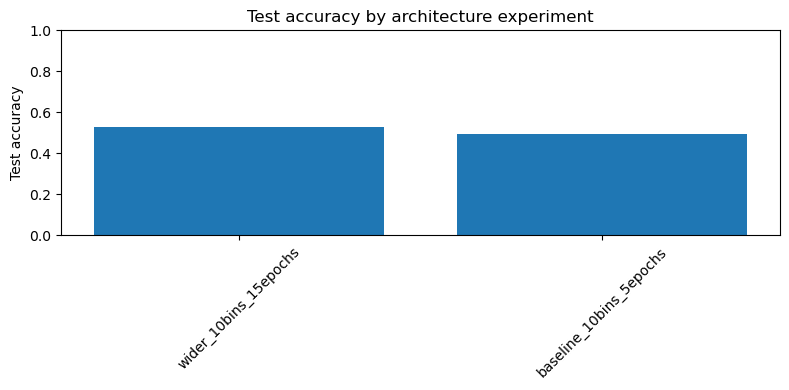

In [8]:
figure, axis = plt.subplots(figsize=(8, 4))
axis.bar(comparison_df["name"], comparison_df["test_acc"])
axis.set_title("Test accuracy by architecture experiment")
axis.set_ylabel("Test accuracy")
axis.set_ylim(0.0, 1.0)
axis.tick_params(axis="x", rotation=45)
figure.tight_layout()
plt.show()

## Selected Experiment Curves

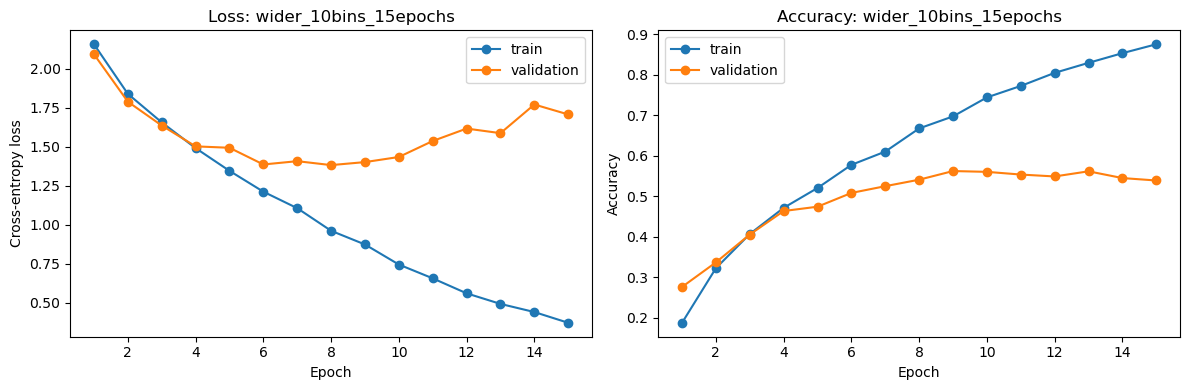

: 

In [ ]:
history = experiment_result["history"]
epochs = [entry.epoch for entry in history]
train_accuracy = [entry.train_accuracy for entry in history]
validation_accuracy = [entry.validation_accuracy for entry in history]
train_loss = [entry.train_loss for entry in history]
validation_loss = [entry.validation_loss for entry in history]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker="o", label="train")
axes[0].plot(epochs, validation_loss, marker="o", label="validation")
axes[0].set_title(f"Loss: {experiment_result['name']}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(epochs, train_accuracy, marker="o", label="train")
axes[1].plot(epochs, validation_accuracy, marker="o", label="validation")
axes[1].set_title(f"Accuracy: {experiment_result['name']}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

figure.tight_layout()
plt.show()